In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

In [28]:
df=pd.read_csv('C:\\Users\\Sowndarya\\OneDrive\\Desktop\\DataAnalytics\\AI&ML\\Project-ML\\Regression_dataset\\insurance.csv')

In [29]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [30]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [31]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [32]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [33]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [35]:
le=LabelEncoder()

In [36]:
df['sex']=le.fit_transform(df['sex'])

In [37]:
df['smoker']=le.fit_transform(df['smoker'])
df['region']=le.fit_transform(df['region'])

In [38]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [39]:
df['bmi']=df['bmi'].astype(int)
df['charges']=df['charges'].astype(int)

In [40]:
df.dtypes

age         int64
sex         int64
bmi         int64
children    int64
smoker      int64
region      int64
charges     int64
dtype: object

In [55]:
s=StandardScaler()

In [58]:
df['charges']=s.fit_transform(df[['charges']])

In [59]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27,0,1,3,0.298548
1,18,1,33,1,0,2,-0.953694
2,28,1,33,3,0,2,-0.728672
3,33,1,22,0,0,1,0.719845
4,32,1,28,0,0,1,-0.776832
...,...,...,...,...,...,...,...
1333,50,1,30,3,0,1,-0.220555
1334,18,0,31,0,0,0,-0.914042
1335,18,0,36,0,0,2,-0.961624
1336,21,0,25,0,0,3,-0.930399


In [60]:
x=df.drop(columns='charges',axis=1)
y=df['charges']

In [61]:
print(x)

      age  sex  bmi  children  smoker  region
0      19    0   27         0       1       3
1      18    1   33         1       0       2
2      28    1   33         3       0       2
3      33    1   22         0       0       1
4      32    1   28         0       0       1
...   ...  ...  ...       ...     ...     ...
1333   50    1   30         3       0       1
1334   18    0   31         0       0       0
1335   18    0   36         0       0       2
1336   21    0   25         0       0       3
1337   61    0   29         0       1       1

[1338 rows x 6 columns]


In [62]:
print(y)

0       0.298548
1      -0.953694
2      -0.728672
3       0.719845
4      -0.776832
          ...   
1333   -0.220555
1334   -0.914042
1335   -0.961624
1336   -0.930399
1337    1.311064
Name: charges, Length: 1338, dtype: float64


In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [64]:
print(x.shape)

(1338, 6)


In [65]:
model=LinearRegression()

In [67]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
y_pred=model.predict(x_test)
print(y_pred)

[-0.95016018 -0.11827494 -0.23110534 -0.89535978 -0.42201447 -0.17671812
 -0.82561834 -0.99610532 -0.08872649 -0.32523787 -0.13786319 -0.67335173
  1.39778751 -1.10837827 -0.05063361  0.00504113 -0.75007889 -0.46403113
  1.35204314 -0.85934501 -0.07657518 -0.93910854  1.73113979  1.56737103
  1.43104989 -0.37372866 -0.90543228  0.16688995 -0.59568305 -0.93920481
 -0.30689453 -0.62336197 -0.76457694 -0.70759324 -0.28993942 -0.69490578
  1.39011686 -0.57685938  1.18298269  0.07314364 -1.08458197  1.21082505
 -0.45596958 -1.01536671 -0.22303598 -0.47687206 -0.15389784 -0.42074141
 -0.18695476  0.0157841  -0.57646966 -1.19685492  1.0551448   1.95713568
 -0.51716132  0.34218828 -1.0109579  -0.18390532 -0.93989443  1.7220348
 -0.15242018 -1.05170834 -0.78927671  1.89453343 -1.22420698  0.0775983
  0.09885676 -0.79012976 -0.02727504 -0.17507918 -0.17248877  0.25698951
 -0.26409197 -0.31832711  0.17383876 -0.09724707 -0.76919816 -0.80006865
 -0.64794416 -0.00768678 -0.37294277 -0.07357686 -0.2

In [69]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [70]:
print(f"mse:",mse)
print(f"r2value:",r2)

mse: 0.26255005843429535
r2value: 0.7438108716916194


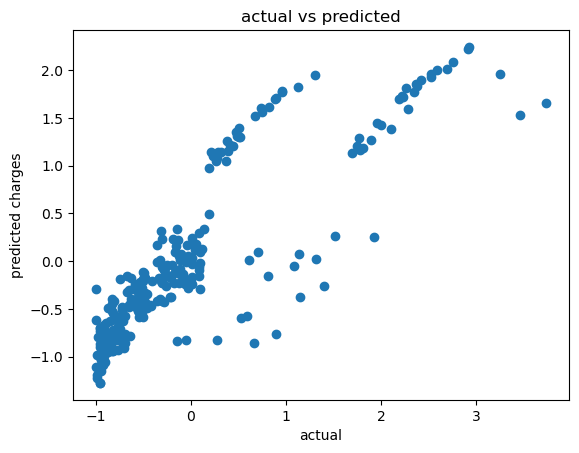

In [71]:
plt.figure()
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted charges")
plt.title("actual vs predicted")
plt.show()

In [72]:
newdata=[[30,0,23,0,0,1]]

In [54]:
output_prdctn=model.predict(newdata)
print(output_prdctn)

[3237.1428968]


C:\Users\Sowndarya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
